https://climada-python.readthedocs.io/en/stable/tutorial/climada_util_api_client.html

https://climada-python.readthedocs.io/en/stable/tutorial/climada_entity_LitPop.html

https://data.iac.ethz.ch/climada/

# **0. Import Library**

In [40]:
!pip install climada

In [41]:
!pip install fiona

In [42]:
from climada.util.api_client import Client
client = Client()


# **1. Finding Datasets: LitPop**

In [103]:
import pandas as pd

data_types = client.list_data_type_infos()

dtf = pd.DataFrame(data_types)
dtf.sort_values(["data_type_group", "data_type"])


,data_type,data_type_group,status,description,properties,key_reference,version_notes
6,centroids,centroids,active,None,"[{'property': 'res_arcsec_land', 'mandatory': ...",[],[]
4,crop_production,exposures,active,Historical and twenty-first century crop produ...,"[{'property': 'crop', 'mandatory': True, 'desc...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....",[]
10,crops,exposures,active,Crop exposure for Switzerland in 2021 obtained...,"[{'property': 'crop', 'mandatory': True, 'desc...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....",[]
0,litpop,exposures,active,A global high-resolution asset exposure datase...,"[{'property': 'spatial_coverage', 'mandatory':...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....","[{'version': 'v2', 'notes': 'Countries with no..."
13,aqueduct_coastal_flood,hazard,active,Global probabilistic coastal flood maps for ba...,"[{'property': 'climate_scenario', 'mandatory':...","[{'ref_no': 1, 'ref_url': 'https://www.wri.org...",[]
8,earthquake,hazard,active,Earthquake hazard sets at 150 arcsec (ca. 4km)...,"[{'property': 'res_arcsec', 'mandatory': True,...","[{'ref_no': 1, 'ref_url': None, 'key_reference...",[]
9,flood,hazard,active,Flood footprint of historical events at a 200m...,"[{'property': 'date_creation', 'mandatory': Tr...",[],[]
12,hail,hazard,active,Radar-based daily hail hazard data at 1km spat...,"[{'property': 'variable', 'mandatory': True, '...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....",[]
7,relative_cropyield,hazard,active,Historical and twenty-first century crop produ...,"[{'property': 'climate_scenario', 'mandatory':...","[{'ref_no': 1, 'ref_url': 'https://doi.org/10....",[]
3,river_flood,hazard,active,River flood [flood depth in meters and flooded...,"[{'property': 'res_arcsec', 'mandatory': True,...","[{'ref_no': 1, 'ref_url': 'https://www.nature....","[{'version': 'v2', 'notes': 'Higher resolution..."


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('data_type_group').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_3['data_type_group'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_3, x='index', y='data_type_group', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [104]:
litpop_dataset_infos = client.list_dataset_infos(data_type="litpop")
all_properties = client.get_property_values(litpop_dataset_infos)
all_properties.keys()


dict_keys(['res_arcsec', 'exponents', 'fin_mode', 'spatial_coverage', 'country_iso3alpha', 'country_name', 'country_iso3num'])

In [105]:
# as datasets are usually available per country, chosing a country or global dataset reduces the options
# here we want to see which datasets are available for litpop globally:
client.get_property_values(
    litpop_dataset_infos, known_property_values={"spatial_coverage": "global"}
)


{'res_arcsec': ['150'],
 'exponents': ['(0,1)', '(1,1)', '(3,0)'],
 'fin_mode': ['pop', 'pc'],
 'spatial_coverage': ['global']}

# **2. TC Impact Calculation of Philippines**

In [106]:
client.get_property_values(
    litpop_dataset_infos, known_property_values={"country_name": "Philippines"}
)

{'res_arcsec': ['150'],
 'exponents': ['(3,0)', '(0,1)', '(1,1)'],
 'fin_mode': ['pc', 'pop'],
 'spatial_coverage': ['country'],
 'country_iso3alpha': ['PHL'],
 'country_name': ['Philippines'],
 'country_iso3num': ['608']}

In [107]:
tc_dataset_infos = client.list_dataset_infos(data_type="tropical_cyclone")
client.get_property_values(
    tc_dataset_infos, known_property_values={"country_name": "Philippines"}
)


{'res_arcsec': ['150'],
 'event_type': ['synthetic', 'observed'],
 'model_name': ['random_walk', 'STORM'],
 'spatial_coverage': ['country'],
 'climate_scenario': ['rcp26', 'rcp45', 'None', 'rcp60', 'rcp85'],
 'ref_year': ['2040', '2060', '2080'],
 'country_iso3alpha': ['PHL'],
 'country_name': ['Philippines'],
 'country_iso3num': ['608'],
 'gcm': ['CMCC-CM2-VHR4', 'CNRM-CM6-1-HR', 'EC-Earth3P-HR']}

**Retrieve Hazard Data**

https://data.iac.ethz.ch/climada/

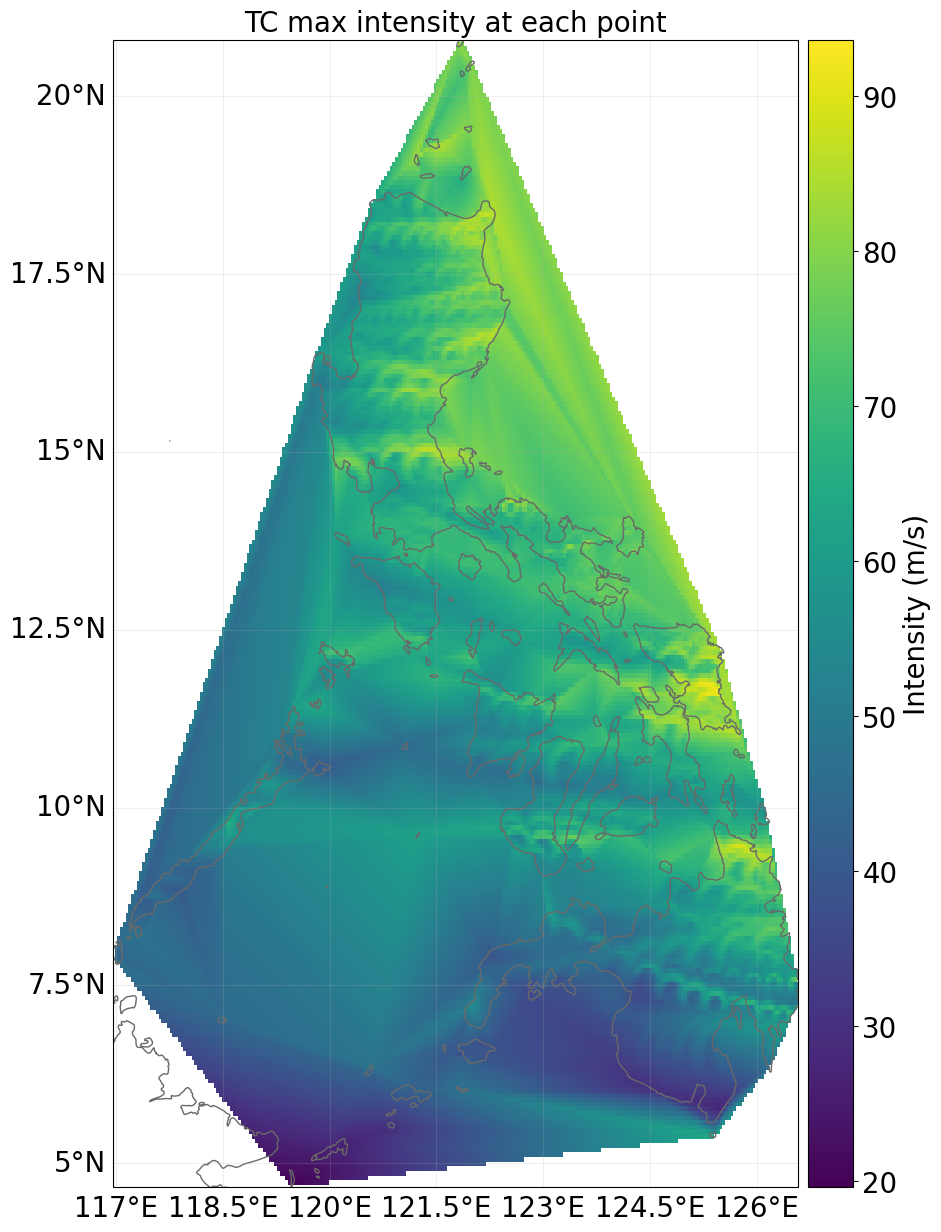

In [121]:
client = Client()
tc_haiti = client.get_hazard(
    "tropical_cyclone",
    properties={
        "country_name": "Philippines",
        "climate_scenario": "rcp26",
        "ref_year": "2040",
        "nb_synth_tracks": "10",
    },
)
tc_haiti.plot_intensity(0);


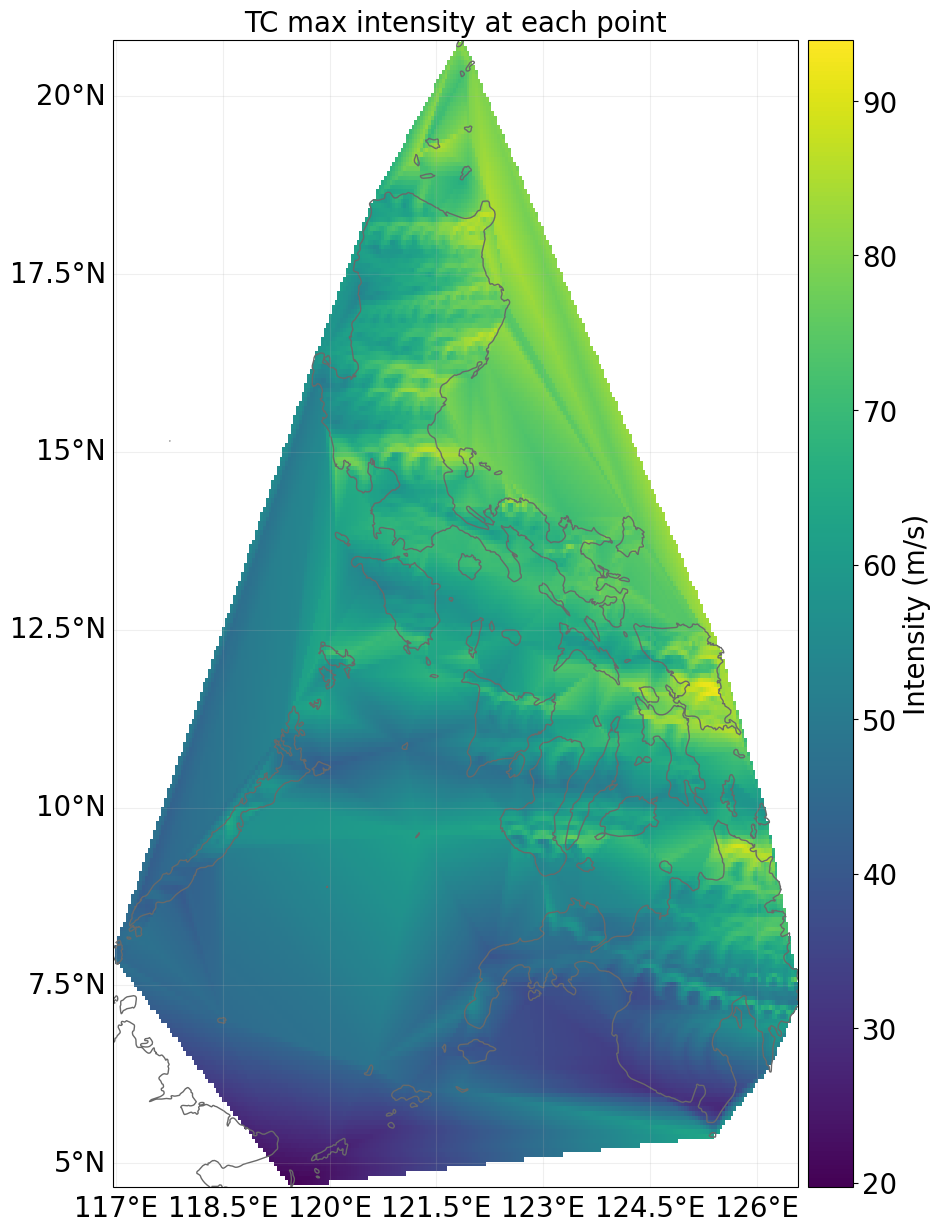

In [122]:
client = Client()
tc_haiti = client.get_hazard(
    "tropical_cyclone",
    properties={
        "country_name": "Philippines",
        "climate_scenario": "rcp60",
        "ref_year": "2040",
        "nb_synth_tracks": "10",
    },
)
tc_haiti.plot_intensity(0);


**Retrieve Exposure Data**

In [111]:
litpop_default = client.get_property_values(
    litpop_dataset_infos, known_property_values={"fin_mode": "pc", "exponents": "(1,1)"}
)


In [112]:
litpop = client.get_litpop(country="Philippines")


<GeoAxes: title={'center': 'LitPop Physical Assets in Philippines (USD)'}>

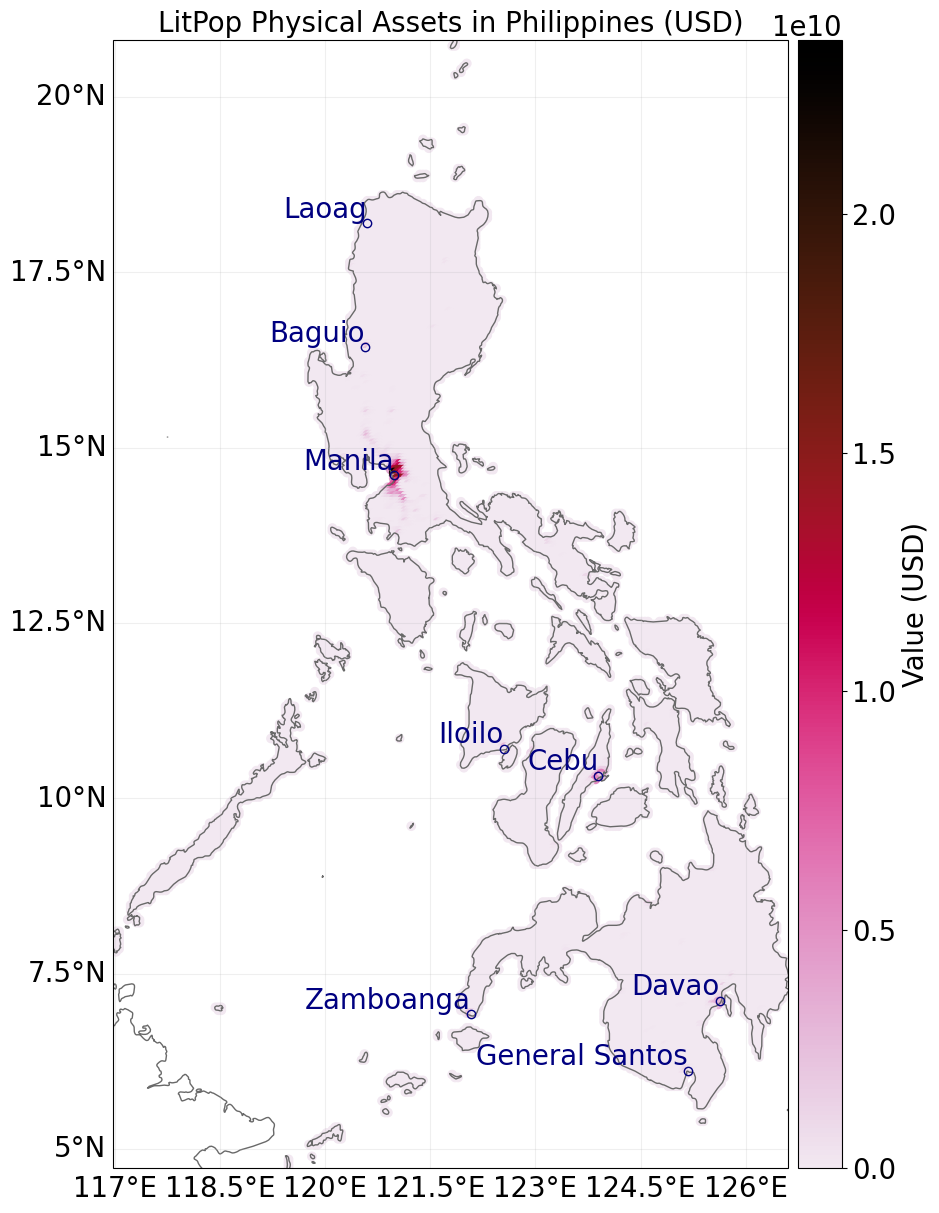

In [113]:
litpop.plot_scatter(title="LitPop Physical Assets in Philippines (USD)")

# **Use a predefined impact function (e.g., for tropical cyclones) to model how hazard intensity affects exposure**

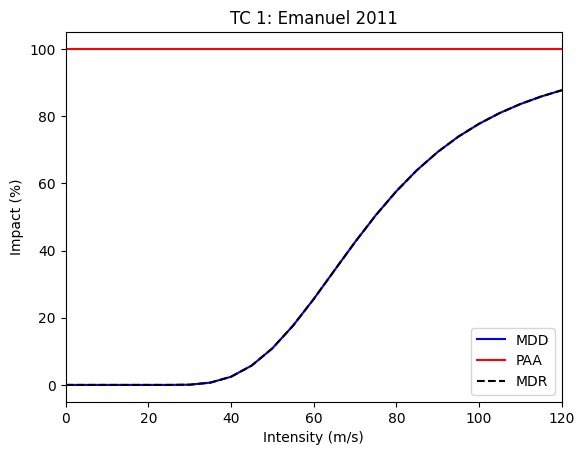

In [123]:
from climada.entity.impact_funcs import ImpactFuncSet, ImpfTropCyclone

imp_fun = ImpfTropCyclone.from_emanuel_usa() # Creates a predefined impact function for tropical cyclones based on the Emanuel (USA) model.
imp_fun.check()
imp_fun.plot()

imp_fun_set = ImpactFuncSet([imp_fun])

litpop.impact_funcs = imp_fun_set


Mean Damage Degree (MDD): Fraction of asset value damaged (0 to 1).


Proportion of Affected Assets (PAA): Fraction of assets affected (often set to 1, assuming all assets in the affected area are impacted).

Example: The Emanuel model might specify that wind speeds below 30 m/s cause no damage (MDD=0), while speeds above 80 m/s cause near-total destruction (MDD=0.9).

# **Calculate Impact**

In [124]:
from climada.engine import ImpactCalc
import numpy as np

impact = ImpactCalc(litpop, imp_fun_set, tc_haiti).impact()
# Exposures.affected_total_value

# Access impact attributes
print("Impact per event (USD):", impact.at_event)
print("Non-zero impacts:", impact.at_event[impact.at_event > 0])
print("Expected annual impact per grid point (USD):", impact.eai_exp)
print("Total expected annual impact (USD):", np.sum(impact.eai_exp))  # Fixed np.sum

# Calculate affected total value (replacing tot_value)
intensity_thr = 30.0  # Wind speed threshold (m/s), adjust based on imp_fun
affected_value = litpop.affected_total_value(tc_haiti, intensity_thr)
print(f"Affected total value: {affected_value} USD")

Impact per event (USD): [0. 0. 0. ... 0. 0. 0.]
Non-zero impacts: [1.62e+06 8.16e+05 5.26e+07 ... 3.30e+09 4.17e+08 1.87e+09]
Expected annual impact per grid point (USD): [     0.        0.        0.   ...  49379.7   24129.37 172425.54]
Total expected annual impact (USD): 7507277387.559007
Affected total value: 732671612318.6565 USD


In [116]:
# Access impact attributes
print("Impact per event (USD):", impact.at_event)
print("Non-zero impacts:", impact.at_event[impact.at_event > 0])

Impact per event (USD): [0. 0. 0. ... 0. 0. 0.]
Non-zero impacts: [1.62e+06 8.16e+05 5.26e+07 ... 3.30e+09 4.17e+08 1.87e+09]


In [117]:
import numpy as np

# Set print options to avoid truncation
np.set_printoptions(threshold=np.inf, linewidth=100, precision=2)

# Print full arrays
print("Impact per event (USD):", impact.at_event)
print("Expected annual impact per grid point (USD):", impact.eai_exp)

# Reset print options to default
np.set_printoptions(threshold=1000, linewidth=75)


串流輸出內容已截斷至最後 5000 行。
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+